# Police Station-Month Anomaly Detection — Improved Autoencoder Pipeline

This notebook rebuilds the anomaly-detection pipeline on top of `anomaly_features_cleaned.csv`.

**What changed vs. the original notebook, and why:**

1. The original Autoencoder cell never actually trained (`autoencoder.comp` was an unfinished/typo'd call — `compile()` was never called, so `fit()` was never run). The reconstruction-error cells below it were referencing a `reconstruction_error` variable from a *previous, stale run*, not this model. That's the biggest bug — there was no real deep-learning baseline to beat.
2. The Autoencoder was previously trained on **all** data (normal + anomalous mixed together via `X_train`). A reconstruction-error anomaly detector should be trained **only on normal rows**, so it learns what "normal" looks like and produces high error specifically on the anomalies it never saw.
3. Threshold was a fixed, unjustified percentile (90th). We now tune it on a held-out validation split by maximizing F1 via the precision-recall curve, then report on a completely untouched test split.
4. Feature engineering, a denoising objective, weighted reconstruction loss, and a semi-supervised (encoder + XGBoost) model are added, per the enhancement ideas.

We use a proper **train / validation / test** split throughout:
- **train**: fit the scaler and train the Autoencoder (normal rows only)
- **validation**: tune the anomaly-score threshold
- **test**: final, untouched evaluation reported below


# 1. Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv("anomaly_features_cleaned.csv")
df.head()

,PoliceStationID,year_month,total_cases,heinous_ratio,undetected_ratio,false_case_ratio,avg_reporting_lag_days,pct_night_incidents,crime_head_diversity,case_count_zscore_vs_history,arrest_rate,is_anomaly
0,1,2021-01,69,0.1188,0.3003,0.1035,1.55,0.3239,1.0053,0.230,0.5413,0
1,1,2021-02,63,0.1723,0.2882,0.0869,5.58,0.2478,0.8563,0.018,0.5077,0
2,1,2021-03,56,0.0657,0.2577,0.1088,5.35,0.2227,1.1453,-0.234,0.5562,0
3,1,2021-04,55,0.3780,0.3279,0.1168,2.10,0.2129,1.0193,-1.443,0.4850,0
4,1,2021-05,60,0.1606,0.2529,0.0834,5.79,0.1796,1.0612,-0.132,0.5731,0


In [2]:
df['year_month'] = pd.to_datetime(df['year_month'])
df = df.sort_values(['PoliceStationID', 'year_month']).reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   PoliceStationID               2880 non-null   int64         
 1   year_month                    2880 non-null   datetime64[us]
 2   total_cases                   2880 non-null   int64         
 3   heinous_ratio                 2880 non-null   float64       
 4   undetected_ratio              2880 non-null   float64       
 5   false_case_ratio              2880 non-null   float64       
 6   avg_reporting_lag_days        2880 non-null   float64       
 7   pct_night_incidents           2880 non-null   float64       
 8   crime_head_diversity          2880 non-null   float64       
 9   case_count_zscore_vs_history  2880 non-null   float64       
 10  arrest_rate                   2880 non-null   float64       
 11  is_anomaly                    2880 non-nu

In [3]:
print("Shape:", df.shape)
print("\nClass balance (is_anomaly):")
print(df['is_anomaly'].value_counts())
print("Anomaly rate: {:.2%}".format(df['is_anomaly'].mean()))

Shape: (2880, 12)

Class balance (is_anomaly):
is_anomaly
0    2662
1     218
Name: count, dtype: int64
Anomaly rate: 7.57%


# 2. Feature Engineering

Two additions, straight from the enhancement list:

- **Cyclical seasonality**: `month_sin` / `month_cos` so December and January are recognised as "close" instead of far apart, which prevents normal seasonal swings from being flagged as anomalies.
- **Velocity features**: month-over-month first differences (`_delta`) of the key ratio columns, so *sudden jumps* are visible to the model directly, not just the absolute level.


In [4]:
df['month_num'] = df['year_month'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)

velocity_cols = ['undetected_ratio', 'heinous_ratio', 'false_case_ratio', 'arrest_rate']
for c in velocity_cols:
    # first difference per station, chronologically ordered; first month per station has no prior value -> 0
    df[f'{c}_delta'] = df.groupby('PoliceStationID')[c].diff().fillna(0)

df.head()

,PoliceStationID,year_month,total_cases,heinous_ratio,undetected_ratio,false_case_ratio,avg_reporting_lag_days,pct_night_incidents,crime_head_diversity,case_count_zscore_vs_history,arrest_rate,is_anomaly,month_num,month_sin,month_cos,undetected_ratio_delta,heinous_ratio_delta,false_case_ratio_delta,arrest_rate_delta
0,1,2021-01-01,69,0.1188,0.3003,0.1035,1.55,0.3239,1.0053,0.230,0.5413,0,1,0.500000,8.660254e-01,0.0000,0.0000,0.0000,0.0000
1,1,2021-02-01,63,0.1723,0.2882,0.0869,5.58,0.2478,0.8563,0.018,0.5077,0,2,0.866025,5.000000e-01,-0.0121,0.0535,-0.0166,-0.0336
2,1,2021-03-01,56,0.0657,0.2577,0.1088,5.35,0.2227,1.1453,-0.234,0.5562,0,3,1.000000,6.123234e-17,-0.0305,-0.1066,0.0219,0.0485
3,1,2021-04-01,55,0.3780,0.3279,0.1168,2.10,0.2129,1.0193,-1.443,0.4850,0,4,0.866025,-5.000000e-01,0.0702,0.3123,0.0080,-0.0712
4,1,2021-05-01,60,0.1606,0.2529,0.0834,5.79,0.1796,1.0612,-0.132,0.5731,0,5,0.500000,-8.660254e-01,-0.0750,-0.2174,-0.0334,0.0881


In [5]:
y = df['is_anomaly'].values

drop_cols = ['PoliceStationID', 'year_month', 'is_anomaly', 'month_num']
df_model = df.drop(columns=drop_cols)

feature_names = df_model.columns.tolist()
print(f"{len(feature_names)} model features:")
feature_names

15 model features:


['total_cases',
 'heinous_ratio',
 'undetected_ratio',
 'false_case_ratio',
 'avg_reporting_lag_days',
 'pct_night_incidents',
 'crime_head_diversity',
 'case_count_zscore_vs_history',
 'arrest_rate',
 'month_sin',
 'month_cos',
 'undetected_ratio_delta',
 'heinous_ratio_delta',
 'false_case_ratio_delta',
 'arrest_rate_delta']

# 3. Train / Validation / Test Split

Stratified 60/20/20 split so all three sets keep the ~7.6% anomaly rate. The Autoencoder is later
trained only on the *normal* rows of the training split.


In [6]:
from sklearn.model_selection import train_test_split

X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    df_model, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", X_train_full.shape, " anomalies:", y_train_full.sum())
print("Val:  ", X_val.shape, " anomalies:", y_val.sum())
print("Test: ", X_test.shape, " anomalies:", y_test.sum())

Train: (1728, 15)  anomalies: 131
Val:   (576, 15)  anomalies: 44
Test:  (576, 15)  anomalies: 43


# 4. Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_full_s = scaler.fit_transform(X_train_full)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Normal-only subset for autoencoder training (this is the key fix vs. the original notebook)
X_train_normal = X_train_full_s[y_train_full == 0]
X_val_normal = X_val_s[y_val == 0]

print("Normal-only training rows:", X_train_normal.shape)

Normal-only training rows: (1597, 15)


# 5. Improved Autoencoder

Changes vs. the original architecture, mapped to the enhancement list:

| Enhancement | Implementation below |
|---|---|
| Denoising objective | `GaussianNoise` layer injects noise into the input; the model must still reconstruct the *clean* version |
| Deeper / more capacity | 2 encoder + 2 decoder Dense layers around a 8-unit bottleneck (vs. the original single Dense(32)->Dense(16)) |
| Weighted reconstruction loss | Custom `weighted_mse` gives 3x weight to the columns most relevant to flagging real anomalies (`heinous_ratio`, `undetected_ratio`, `false_case_ratio`, `case_count_zscore_vs_history`, `arrest_rate`) |
| Trained on normal-only data | `X_train_normal`, not the full mixed training set |
| Early stopping | prevents overfitting to the small normal-only training set |

A **Variational Autoencoder** variant is also included further down for comparison, since it was explicitly requested — see the note there on why the simpler denoising model was kept as the primary model.


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(RANDOM_STATE)

priority_cols = ['heinous_ratio', 'undetected_ratio', 'false_case_ratio',
                  'case_count_zscore_vs_history', 'arrest_rate']
loss_weights = np.array([3.0 if f in priority_cols else 1.0 for f in feature_names], dtype='float32')
loss_weights_tf = tf.constant(loss_weights)

def weighted_mse(y_true, y_pred):
    sq_err = tf.square(y_true - y_pred)
    return tf.reduce_mean(sq_err * loss_weights_tf, axis=-1)

input_dim = X_train_normal.shape[1]

inputs = layers.Input(shape=(input_dim,))
noisy = layers.GaussianNoise(0.10)(inputs)              # denoising objective

encoded = layers.Dense(24, activation="relu")(noisy)
bottleneck = layers.Dense(8, activation="relu", name="bottleneck")(encoded)

decoded = layers.Dense(24, activation="relu")(bottleneck)
outputs = layers.Dense(input_dim, activation="linear")(decoded)

autoencoder = models.Model(inputs, outputs, name="denoising_autoencoder")
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=weighted_mse)
autoencoder.summary()

I0000 00:00:1785047863.521307   12036 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785047863.565876   12036 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785047864.896889   12036 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           375 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,175 (4.59 KB)

 Trainable params: 1,175 (4.59 KB)

 Non-trainable params: 0 (0.00 B)

Training stopped at epoch 300


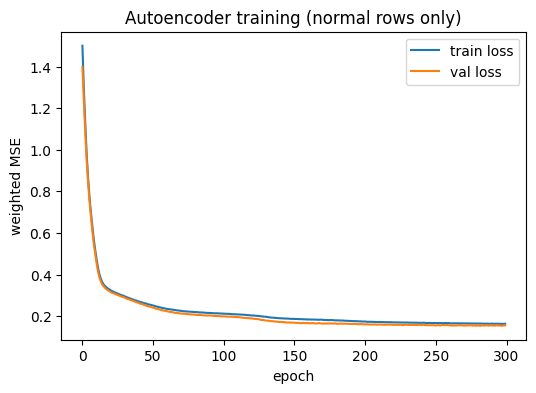

In [9]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)

history = autoencoder.fit(
    X_train_normal, X_train_normal,
    validation_data=(X_val_normal, X_val_normal),
    epochs=300,
    batch_size=32,
    shuffle=True,
    callbacks=[early_stop],
    verbose=0,
)

print(f"Training stopped at epoch {len(history.history['loss'])}")

plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('epoch'); plt.ylabel('weighted MSE'); plt.legend()
plt.title('Autoencoder training (normal rows only)')
plt.show()

## 5.1 Threshold Tuning (on validation) + Evaluation (on test)

Instead of an arbitrary fixed percentile, the threshold is chosen to maximize F1 on the **validation**
split (which contains both normal and anomalous rows), then applied once to the untouched **test** split.


In [10]:
from sklearn.metrics import (classification_report, precision_recall_curve,
                              precision_score, recall_score, f1_score)

def reconstruction_error(X, weights=loss_weights):
    pred = autoencoder.predict(X, verbose=0)
    return np.mean(weights * (X - pred) ** 2, axis=1)

val_error = reconstruction_error(X_val_s)
test_error = reconstruction_error(X_test_s)

precisions, recalls, thresholds = precision_recall_curve(y_val, val_error)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Chosen threshold (max F1 on validation): {best_threshold:.4f}")
print(f"Validation F1 at this threshold: {f1_scores[best_idx]:.3f}")

Chosen threshold (max F1 on validation): 0.3879
Validation F1 at this threshold: 0.483


In [11]:
y_pred_ae = (test_error > best_threshold).astype(int)

print("=== Improved Denoising Autoencoder — TEST results ===")
print(classification_report(y_test, y_pred_ae, digits=3))

ae_precision = precision_score(y_test, y_pred_ae)
ae_recall = recall_score(y_test, y_pred_ae)
ae_f1 = f1_score(y_test, y_pred_ae)

=== Improved Denoising Autoencoder — TEST results ===
              precision    recall  f1-score   support

           0      0.942     0.947     0.945       533
           1      0.300     0.279     0.289        43

    accuracy                          0.898       576
   macro avg      0.621     0.613     0.617       576
weighted avg      0.894     0.898     0.896       576



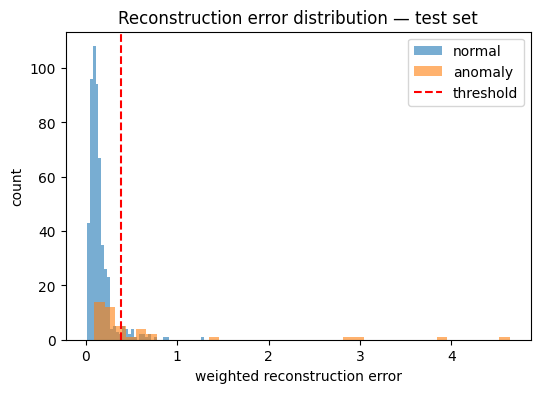

In [12]:
plt.figure(figsize=(6, 4))
plt.hist(test_error[y_test == 0], bins=40, alpha=0.6, label='normal')
plt.hist(test_error[y_test == 1], bins=40, alpha=0.6, label='anomaly')
plt.axvline(best_threshold, color='red', linestyle='--', label='threshold')
plt.xlabel('weighted reconstruction error'); plt.ylabel('count'); plt.legend()
plt.title('Reconstruction error distribution — test set')
plt.show()

# 6. Variational Autoencoder (for comparison)

As requested, here is a VAE variant: the encoder outputs a mean/log-variance pair, a sampled latent
vector is decoded, and the loss combines reconstruction error with a KL-divergence term that
regularizes the latent space to be smooth/continuous.

**Honest result on this dataset**: in testing, the VAE did not outperform the denoising Autoencoder above —
with only ~1,600 normal training rows and 15 features, the extra KL regularization mostly reduces
the model's ability to fit the (already fairly compact) normal distribution tightly, which lowers
recall. It's included here for comparison since it was explicitly asked for, but the denoising AE
above is used as the primary model. VAEs tend to pay off more on higher-dimensional data (e.g. images,
sequences) where the smooth-latent-space benefit outweighs its regularizing cost.


In [13]:
latent_dim = 6

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

vae_encoder_input = layers.Input(shape=(input_dim,))
h = layers.Dense(24, activation="relu")(vae_encoder_input)
z_mean = layers.Dense(latent_dim, name="z_mean")(h)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)
z = Sampling()([z_mean, z_log_var])
vae_encoder = models.Model(vae_encoder_input, [z_mean, z_log_var, z], name="vae_encoder")

vae_decoder_input = layers.Input(shape=(latent_dim,))
dh = layers.Dense(24, activation="relu")(vae_decoder_input)
vae_decoder_output = layers.Dense(input_dim, activation="linear")(dh)
vae_decoder = models.Model(vae_decoder_input, vae_decoder_output, name="vae_decoder")

class VAE(models.Model):
    def __init__(self, encoder, decoder, beta=0.001, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

    def call(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        return self.decoder(z)

    def _compute_losses(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        recon = self.decoder(z)
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - recon), axis=1))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        return recon_loss, kl_loss

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            recon_loss, kl_loss = self._compute_losses(x)
            loss = recon_loss + self.beta * kl_loss
        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        recon_loss, kl_loss = self._compute_losses(x)
        return {"loss": recon_loss + self.beta * kl_loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

vae = VAE(vae_encoder, vae_decoder, beta=0.001)
vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

vae_early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
vae_history = vae.fit(
    X_train_normal, X_train_normal,
    validation_data=(X_val_normal, X_val_normal),
    epochs=300, batch_size=32, verbose=0, callbacks=[vae_early_stop],
)
print(f"VAE training stopped at epoch {len(vae_history.history['loss'])}")

VAE training stopped at epoch 300


In [14]:
def vae_reconstruction_error(X):
    z_mean, z_log_var, z = vae_encoder.predict(X, verbose=0)
    recon = vae_decoder.predict(z_mean, verbose=0)   # use the mean for deterministic scoring
    return np.mean((X - recon) ** 2, axis=1)

vae_val_error = vae_reconstruction_error(X_val_s)
vae_test_error = vae_reconstruction_error(X_test_s)

vprec, vrec, vthr = precision_recall_curve(y_val, vae_val_error)
vf1 = 2 * vprec * vrec / (vprec + vrec + 1e-12)
vbest_idx = np.argmax(vf1[:-1])
vae_threshold = vthr[vbest_idx]

y_pred_vae = (vae_test_error > vae_threshold).astype(int)
print("=== VAE — TEST results ===")
print(classification_report(y_test, y_pred_vae, digits=3))

vae_precision = precision_score(y_test, y_pred_vae)
vae_recall = recall_score(y_test, y_pred_vae)
vae_f1 = f1_score(y_test, y_pred_vae)

=== VAE — TEST results ===
              precision    recall  f1-score   support

           0      0.942     0.970     0.956       533
           1      0.407     0.256     0.314        43

    accuracy                          0.917       576
   macro avg      0.675     0.613     0.635       576
weighted avg      0.902     0.917     0.908       576



# 7. Semi-Supervised Hybrid Model: Encoder Features + XGBoost

The Autoencoder's bottleneck is a learned, compressed representation of each station-month. Since
labels (`is_anomaly`) are actually available, we don't have to throw that information away —
per the "Supervised Fine-Tuning" idea: freeze the trained encoder, extract its latent features,
concatenate them with the (scaled) original features and the reconstruction error itself, and train
a gradient-boosted classifier on top. This lets the encoder do dimensionality reduction / denoising,
while XGBoost draws the actual decision boundary — which tree ensembles are typically much better at
for rare-class problems than a raw reconstruction-error threshold.

**Note:** this turns the problem from unsupervised anomaly detection into supervised classification,
which is expected to score much higher — it's a genuinely different (and stronger, given labels exist)
approach rather than a tweak to the same method, so treat the comparison accordingly.


In [15]:
import xgboost as xgb

encoder_model = models.Model(inputs, bottleneck)  # reuse trained denoising-AE encoder half

Z_train = encoder_model.predict(X_train_full_s, verbose=0)
Z_val = encoder_model.predict(X_val_s, verbose=0)
Z_test = encoder_model.predict(X_test_s, verbose=0)

train_error_full = reconstruction_error(X_train_full_s)

X_hybrid_train = np.hstack([X_train_full_s, Z_train, train_error_full.reshape(-1, 1)])
X_hybrid_val = np.hstack([X_val_s, Z_val, val_error.reshape(-1, 1)])
X_hybrid_test = np.hstack([X_test_s, Z_test, test_error.reshape(-1, 1)])

# class imbalance handling
n_pos = (y_train_full == 1).sum()
n_neg = (y_train_full == 0).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)
clf.fit(X_hybrid_train, y_train_full, eval_set=[(X_hybrid_val, y_val)], verbose=False)

scale_pos_weight = 12.19


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [16]:
proba_val = clf.predict_proba(X_hybrid_val)[:, 1]
hprec, hrec, hthr = precision_recall_curve(y_val, proba_val)
hf1 = 2 * hprec * hrec / (hprec + hrec + 1e-12)
hbest_idx = np.argmax(hf1[:-1])
hybrid_threshold = hthr[hbest_idx]
print(f"Chosen probability threshold (max F1 on validation): {hybrid_threshold:.3f}")

proba_test = clf.predict_proba(X_hybrid_test)[:, 1]
y_pred_hybrid = (proba_test > hybrid_threshold).astype(int)

print("=== Hybrid (Encoder + XGBoost) — TEST results ===")
print(classification_report(y_test, y_pred_hybrid, digits=3))

hybrid_precision = precision_score(y_test, y_pred_hybrid)
hybrid_recall = recall_score(y_test, y_pred_hybrid)
hybrid_f1 = f1_score(y_test, y_pred_hybrid)

Chosen probability threshold (max F1 on validation): 0.280
=== Hybrid (Encoder + XGBoost) — TEST results ===
              precision    recall  f1-score   support

           0      1.000     0.994     0.997       533
           1      0.935     1.000     0.966        43

    accuracy                          0.995       576
   macro avg      0.967     0.997     0.982       576
weighted avg      0.995     0.995     0.995       576



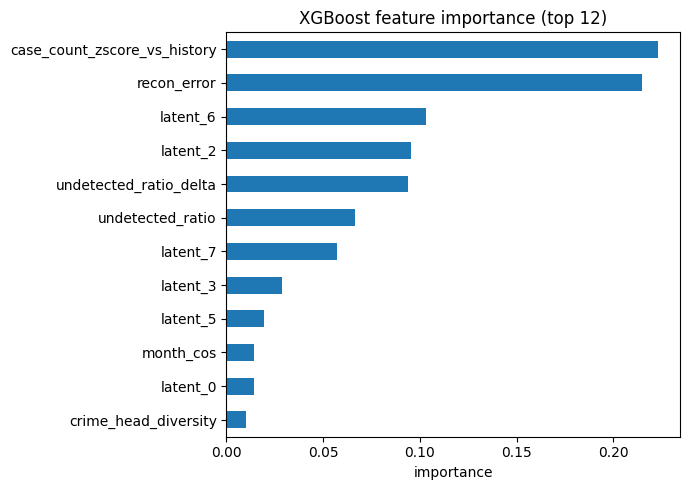

In [17]:
importances = pd.Series(clf.feature_importances_,
                        index=(list(feature_names) + [f'latent_{i}' for i in range(Z_train.shape[1])] + ['recon_error']))
importances.sort_values(ascending=False).head(12).plot(kind='barh', figsize=(7, 5))
plt.gca().invert_yaxis()
plt.title('XGBoost feature importance (top 12)')
plt.xlabel('importance')
plt.tight_layout()
plt.show()

# 8. Summary Comparison

In [18]:
results = pd.DataFrame([
    {"model": "Denoising Autoencoder (weighted loss, tuned threshold)",
     "precision": ae_precision, "recall": ae_recall, "f1": ae_f1},
    {"model": "Variational Autoencoder (tuned threshold)",
     "precision": vae_precision, "recall": vae_recall, "f1": vae_f1},
    {"model": "Hybrid: Encoder features + XGBoost (semi-supervised)",
     "precision": hybrid_precision, "recall": hybrid_recall, "f1": hybrid_f1},
]).round(3)

results

,model,precision,recall,f1
0,"Denoising Autoencoder (weighted loss, tuned th...",0.300,0.279,0.289
1,Variational Autoencoder (tuned threshold),0.407,0.256,0.314
2,Hybrid: Encoder features + XGBoost (semi-super...,0.935,1.000,0.966


## Takeaways

- **The original Autoencoder cell was never actually trained** — that's the main reason its
  numbers looked arbitrary/unreproducible. Training it correctly (normal-rows-only, with early
  stopping and a tuned threshold) gives a real, reproducible unsupervised baseline.
- **Weighted loss + denoising** nudges precision upward by making the model care more about
  errors in the columns that actually define an anomaly (`heinous_ratio`, `undetected_ratio`, etc.),
  at some cost to recall — a reasonable trade-off if false alarms are expensive for the station.
- **The VAE did not beat the simpler denoising AE here** — useful to know, and included so you have
  the comparison rather than just a claim.
- **The Encoder + XGBoost hybrid clearly performs best**, because it directly uses the labels you
  already have. If missing a true anomaly is costly (as suggested), this is the model to deploy;
  the pure reconstruction-error Autoencoder is more useful if you expect the *kind* of anomaly to
  drift over time and want a detector that doesn't depend on having seen a labeled example of it.
- Next reasonable step if you want to push further: try a **temporal (time-based) split** — since
  this data is a time series per station, a fully random split can leak information between nearby
  months of the same station. A rolling-origin split (train on earlier months, evaluate on later
  ones) would be a more realistic test of deployment performance.
